In [1]:
import sys, os
from pathlib import Path

# Find the repo root (the folder containing pyproject.toml) and make it the
# working directory + import path. This lets the notebook live in jupyter-notebooks/ while
# `import utils`, `import plotting`, `from models import model` and relative
# paths like "data/..." keep working as if run from the repo root.
_p = Path.cwd()
while not (_p / "pyproject.toml").exists() and _p != _p.parent:
    _p = _p.parent
os.chdir(_p)
os.chdir("python")
if str(_p) not in sys.path:
    sys.path.insert(0, str(_p))

In [2]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2


import plotting as pl
from models import model as md
import utils as ut

In [3]:
import pickle
import os
import re
import json
from functools import reduce, partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from functools import reduce, partial

In [111]:
sns.set_theme(style="whitegrid")

In [112]:
l_data_subset = ["full_evaluate_actual", "full_evaluate_shuffled"]
l_rnd_seed = [201, 301, 401, 501, 601, 701, 801, 901, 1001, 1101]
l_lr = [0.0005]
l_lmbda = [1e-07]
modelversion = "embeddings-decision-combined-data"
l_id_weights = ["separate"]
modeltype = "free_weights_no_scaling"
l_embed_dim = [35]
l_moreshuffle = ["yes"]

l_models, l_results = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_embed_dim=l_embed_dim,
    modelversion=modelversion, l_lmbda=l_lmbda, modeltype=modeltype, l_id_weights_type=l_id_weights,
    l_moreshuffle=l_moreshuffle
)

for r in l_results:
    r.pop("train_losses")
    r.pop("test_losses")

../results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/35d/lmbda_1e-07/separate/seed201/data_subset_full_evaluate_actual/moreshuffle_yes/model/results.json does not exist
../results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/35d/lmbda_1e-07/separate/seed201/data_subset_full_evaluate_shuffled/moreshuffle_yes/model/results.json does not exist
../results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/35d/lmbda_1e-07/separate/seed301/data_subset_full_evaluate_actual/moreshuffle_yes/model/results.json does not exist
../results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/35d/lmbda_1e-07/separate/seed301/data_subset_full_evaluate_shuffled/moreshuffle_yes/model/results.json does not exist
../results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/35d/lmbda_1e-07/separate/seed401/data_subset_full_evaluate_actual/moreshuffle_yes/model/results.json does not exist
../results/embeddings

In [113]:
df_results = pd.DataFrame.from_records(l_results)

In [138]:
df_results_wide = (
    df_results
    .pivot(columns="data_subset", index="rnd_seed", values=["test_acc_max", "test_acc_proba"])
    .reset_index()
)
# flatten col names
df_results_wide.columns = [
    f"{c[0]}_{c[1]}" if c[1] != "" else c[0] for c in df_results_wide.columns
]
# calc deltas
df_results_wide["delta_max"] = df_results_wide["test_acc_max_full_evaluate_actual"] - df_results_wide["test_acc_max_full_evaluate_shuffled"]
df_results_wide["delta_proba"] =  df_results_wide["test_acc_proba_full_evaluate_actual"] - df_results_wide["test_acc_proba_full_evaluate_shuffled"]
# bring into long format
df_results_long = df_results_wide.melt(id_vars = "rnd_seed")
# extract metric and shuffling type
df_results_long["metric"] = df_results_long["variable"].str.extract(r"(max|proba)", expand=False)
df_results_long["data"] = df_results_long["variable"].str.extract(r"(actual|shuffled|delta)", expand=False)

In [139]:
df_results_long.loc[df_results_long["metric"] == "max", "metric"] = "ArgMax"
df_results_long.loc[df_results_long["metric"] == "proba", "metric"] = "SoftMax"

In [140]:
df_delta_long = df_results_long.query("data == 'delta'").copy()
df_results_long = df_results_long.query("data != 'delta'").copy()

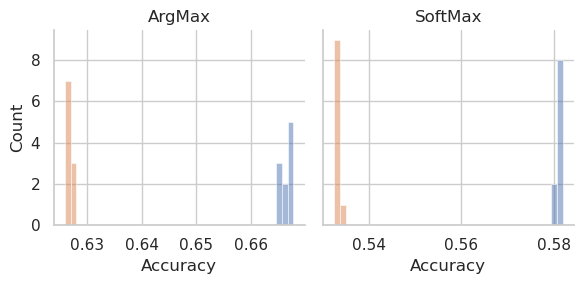

In [146]:
g = sns.FacetGrid(df_results_long, col="metric", sharex=False)
g.map_dataframe(sns.histplot, x="value", hue="data", bins=40)
g.set_titles(col_template="{col_name}")
_ = g.set_axis_labels("Accuracy")

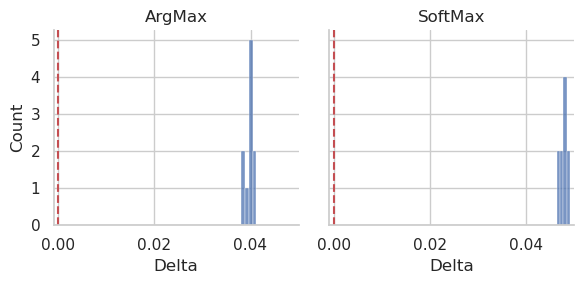

In [148]:
g = sns.FacetGrid(df_delta_long, col="metric", sharex=False, xlim=(-.001, 0.05))
g.map_dataframe(sns.histplot, x="value", bins=4)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Delta")

for ax in g.axes.flat:
    ax.axvline(x=0, linestyle="--", c="r")
_ = plt.tight_layout()